# BÀI TẬP LỚN CUỐI KHÓA — CSE703185
## Lập trình cho Phân tích Dữ liệu

**Đề tài:** Hệ thống phân tích dữ liệu kinh doanh cho Phenikaa Commerce  
**Dữ liệu:** Bộ dữ liệu mô phỏng do nhóm tự tạo bằng NumPy/random, có cố định `np.random.seed(703185)` để tái lập kết quả.  
**Quy mô:** 360 đơn hàng gốc; sau khi chủ động bổ sung 3 hàng trùng để kiểm thử, dữ liệu thô có 363 bản ghi. Sau làm sạch còn 360 bản ghi hợp lệ.

> Trước khi nộp, sinh viên cần điền Họ tên, MSSV, lớp, email, link GitHub và link video vào Phiếu trả lời/README.

In [1]:
# Thiết lập thư viện và môi trường chạy
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Bảo đảm chạy ổn định khi Restart & Run All ở môi trường không có giao diện
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from IPython.display import display, Image, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Khi chạy notebook, ảnh sẽ được lưu ngay cùng thư mục notebook.
OUTPUT_DIR = Path.cwd()
MATPLOTLIB_FILE = OUTPUT_DIR / "dashboard_matplotlib.png"
SEABORN_FILE = OUTPUT_DIR / "dashboard_seaborn.png"
PAIRPLOT_FILE = OUTPUT_DIR / "pairplot_seaborn.png"

RANDOM_SEED = 703185
np.random.seed(RANDOM_SEED)
print(f"Đã thiết lập môi trường. RANDOM_SEED = {RANDOM_SEED}")

Đã thiết lập môi trường. RANDOM_SEED = 703185


# PHẦN 1 — NỀN TẢNG LẬP TRÌNH PYTHON

Phần này sử dụng có chủ đích `List`, `Dict`, `Set`, `Tuple`, hàm, `**kwargs`, `filter`, `map`, `sorted` và list comprehension.

In [2]:
# 1.1. Tạo dữ liệu thô bằng cấu trúc Python thuần
# List chứa 20 Dict; mỗi Dict biểu diễn một đơn hàng.
ds_don_hang = [
    {"ma_don": "DH001", "ma_kh": "KH001", "ngay_dat": "2026-01-03", "khu_vuc": "HN", "kenh_ban": "Website", "danh_muc": "Công nghệ", "gia_tri": 12_500_000, "trang_thai": "done"},
    {"ma_don": "DH002", "ma_kh": "KH002", "ngay_dat": "2026-01-05", "khu_vuc": "HCM", "kenh_ban": "Zalo", "danh_muc": "Văn phòng", "gia_tri": 4_800_000, "trang_thai": "cancelled"},
    {"ma_don": "DH003", "ma_kh": "KH003", "ngay_dat": "2026-01-06", "khu_vuc": "HN", "kenh_ban": "Sales trực tiếp", "danh_muc": "Vật tư", "gia_tri": 18_200_000, "trang_thai": "done"},
    {"ma_don": "DH004", "ma_kh": "KH004", "ngay_dat": "2026-01-08", "khu_vuc": "Đà Nẵng", "kenh_ban": "Sàn B2B", "danh_muc": "Gia dụng", "gia_tri": 7_600_000, "trang_thai": "processing"},
    {"ma_don": "DH005", "ma_kh": "KH005", "ngay_dat": "2026-01-09", "khu_vuc": "HCM", "kenh_ban": "Website", "danh_muc": "Công nghệ", "gia_tri": 22_300_000, "trang_thai": "done"},
    {"ma_don": "DH006", "ma_kh": "KH001", "ngay_dat": "2026-01-11", "khu_vuc": "Hải Phòng", "kenh_ban": "Zalo", "danh_muc": "Vật tư", "gia_tri": 3_900_000, "trang_thai": "done"},
    {"ma_don": "DH007", "ma_kh": "KH006", "ngay_dat": "2026-01-12", "khu_vuc": "HN", "kenh_ban": "Sàn B2B", "danh_muc": "Văn phòng", "gia_tri": 9_700_000, "trang_thai": "done"},
    {"ma_don": "DH008", "ma_kh": "KH007", "ngay_dat": "2026-01-15", "khu_vuc": "Cần Thơ", "kenh_ban": "Website", "danh_muc": "Gia dụng", "gia_tri": 6_200_000, "trang_thai": "cancelled"},
    {"ma_don": "DH009", "ma_kh": "KH008", "ngay_dat": "2026-01-16", "khu_vuc": "HCM", "kenh_ban": "Sales trực tiếp", "danh_muc": "Công nghệ", "gia_tri": 27_600_000, "trang_thai": "done"},
    {"ma_don": "DH010", "ma_kh": "KH009", "ngay_dat": "2026-01-18", "khu_vuc": "Đà Nẵng", "kenh_ban": "Website", "danh_muc": "Văn phòng", "gia_tri": 5_400_000, "trang_thai": "processing"},
    {"ma_don": "DH011", "ma_kh": "KH010", "ngay_dat": "2026-01-20", "khu_vuc": "HN", "kenh_ban": "Zalo", "danh_muc": "Gia dụng", "gia_tri": 2_700_000, "trang_thai": "cancelled"},
    {"ma_don": "DH012", "ma_kh": "KH002", "ngay_dat": "2026-01-22", "khu_vuc": "HCM", "kenh_ban": "Sàn B2B", "danh_muc": "Vật tư", "gia_tri": 14_100_000, "trang_thai": "done"},
    {"ma_don": "DH013", "ma_kh": "KH011", "ngay_dat": "2026-01-24", "khu_vuc": "Hải Phòng", "kenh_ban": "Website", "danh_muc": "Công nghệ", "gia_tri": 11_800_000, "trang_thai": "done"},
    {"ma_don": "DH014", "ma_kh": "KH012", "ngay_dat": "2026-01-25", "khu_vuc": "HN", "kenh_ban": "Sales trực tiếp", "danh_muc": "Văn phòng", "gia_tri": 16_900_000, "trang_thai": "done"},
    {"ma_don": "DH015", "ma_kh": "KH013", "ngay_dat": "2026-01-27", "khu_vuc": "Cần Thơ", "kenh_ban": "Zalo", "danh_muc": "Vật tư", "gia_tri": 4_300_000, "trang_thai": "processing"},
    {"ma_don": "DH016", "ma_kh": "KH014", "ngay_dat": "2026-01-29", "khu_vuc": "HCM", "kenh_ban": "Website", "danh_muc": "Gia dụng", "gia_tri": 8_500_000, "trang_thai": "done"},
    {"ma_don": "DH017", "ma_kh": "KH015", "ngay_dat": "2026-02-01", "khu_vuc": "Đà Nẵng", "kenh_ban": "Sales trực tiếp", "danh_muc": "Công nghệ", "gia_tri": 31_200_000, "trang_thai": "done"},
    {"ma_don": "DH018", "ma_kh": "KH003", "ngay_dat": "2026-02-03", "khu_vuc": "HN", "kenh_ban": "Sàn B2B", "danh_muc": "Gia dụng", "gia_tri": 10_600_000, "trang_thai": "done"},
    {"ma_don": "DH019", "ma_kh": "KH016", "ngay_dat": "2026-02-04", "khu_vuc": "Hải Phòng", "kenh_ban": "Zalo", "danh_muc": "Văn phòng", "gia_tri": 3_200_000, "trang_thai": "cancelled"},
    {"ma_don": "DH020", "ma_kh": "KH017", "ngay_dat": "2026-02-06", "khu_vuc": "HCM", "kenh_ban": "Website", "danh_muc": "Vật tư", "gia_tri": 13_700_000, "trang_thai": "done"},
]

# Set dùng để lưu danh sách khu vực duy nhất, giúp tránh trùng lặp khi kiểm tra phạm vi kinh doanh.
tap_khu_vuc = {don["khu_vuc"] for don in ds_don_hang}

# Tuple dùng cho cấu hình bất biến: thứ tự các trạng thái hợp lệ của hệ thống.
TRANG_THAI_HOP_LE = ("done", "processing", "cancelled")

# Dict dùng để ánh xạ mã trạng thái sang diễn giải tiếng Việt.
MO_TA_TRANG_THAI = {
    "done": "Hoàn thành",
    "processing": "Đang xử lý",
    "cancelled": "Đã hủy",
}

print(f"Số đơn hàng: {len(ds_don_hang)}")
print(f"Các khu vực duy nhất (Set): {sorted(tap_khu_vuc)}")
print(f"Trạng thái hợp lệ (Tuple): {TRANG_THAI_HOP_LE}")
print("Đơn hàng đầu tiên (Dict):", ds_don_hang[0])

Số đơn hàng: 20
Các khu vực duy nhất (Set): ['Cần Thơ', 'HCM', 'HN', 'Hải Phòng', 'Đà Nẵng']
Trạng thái hợp lệ (Tuple): ('done', 'processing', 'cancelled')
Đơn hàng đầu tiên (Dict): {'ma_don': 'DH001', 'ma_kh': 'KH001', 'ngay_dat': '2026-01-03', 'khu_vuc': 'HN', 'kenh_ban': 'Website', 'danh_muc': 'Công nghệ', 'gia_tri': 12500000, 'trang_thai': 'done'}


In [3]:
# 1.2. Xây dựng các hàm xử lý và thống kê dữ liệu

def loc_don_hang(ds, **tieu_chi):
    """Lọc danh sách đơn hàng theo nhiều tiêu chí tùy ý.

    Args:
        ds (list[dict]): Danh sách đơn hàng.
        **tieu_chi: Các cặp trường=giá trị cần lọc.

    Returns:
        list[dict]: Các đơn hàng thỏa mãn đồng thời toàn bộ tiêu chí.
    """
    truong_khong_hop_le = set(tieu_chi) - set(ds[0]) if ds else set()
    if truong_khong_hop_le:
        raise KeyError(f"Trường lọc không tồn tại: {sorted(truong_khong_hop_le)}")
    return [don for don in ds if all(don.get(k) == v for k, v in tieu_chi.items())]


def thong_ke_theo_nhom(ds, truong_nhom):
    """Tổng hợp số đơn, doanh thu, giá trị trung bình và tỷ lệ hoàn thành theo nhóm.

    Args:
        ds (list[dict]): Danh sách đơn hàng.
        truong_nhom (str): Tên trường phân loại, ví dụ ``kenh_ban`` hoặc ``khu_vuc``.

    Returns:
        dict: Cấu trúc {nhóm: {so_don, tong_gia_tri, gia_tri_tb, ty_le_hoan_thanh}}.
    """
    if not ds:
        return {}
    if truong_nhom not in ds[0]:
        raise KeyError(f"Không tồn tại trường nhóm: {truong_nhom}")

    nhom_du_lieu = defaultdict(list)
    for don in ds:
        nhom_du_lieu[don[truong_nhom]].append(don)

    ket_qua = {}
    for nhom, cac_don in nhom_du_lieu.items():
        tong_gia_tri = sum(don["gia_tri"] for don in cac_don)
        so_hoan_thanh = sum(don["trang_thai"] == "done" for don in cac_don)
        ket_qua[nhom] = {
            "so_don": len(cac_don),
            "tong_gia_tri": tong_gia_tri,
            "gia_tri_tb": tong_gia_tri / len(cac_don),
            "ty_le_hoan_thanh": so_hoan_thanh / len(cac_don) * 100,
        }
    return ket_qua


def phan_khuc_don_hang(ds):
    """Gắn phân khúc Giá trị thấp/Trung bình/Cao cho từng đơn hàng.

    Ngưỡng được lựa chọn theo bối cảnh B2B mô phỏng:
    dưới 5 triệu là đơn nhỏ; từ 5 đến dưới 15 triệu là đơn trung bình;
    từ 15 triệu trở lên là đơn giá trị cao.

    Args:
        ds (list[dict]): Danh sách đơn hàng.

    Returns:
        list[dict]: Bản sao dữ liệu có thêm trường ``phan_khuc``.
    """
    ket_qua = []
    for don in ds:
        ban_sao = don.copy()
        if don["gia_tri"] < 5_000_000:
            ban_sao["phan_khuc"] = "Thấp"
        elif don["gia_tri"] < 15_000_000:
            ban_sao["phan_khuc"] = "Trung bình"
        else:
            ban_sao["phan_khuc"] = "Cao"
        ket_qua.append(ban_sao)
    return ket_qua


def bao_cao_tom_tat(ds):
    """In Executive Summary ngắn từ danh sách đơn hàng.

    Args:
        ds (list[dict]): Danh sách đơn hàng.

    Returns:
        dict: Các KPI chính để có thể tái sử dụng ở bước khác.
    """
    if not ds:
        print("Không có dữ liệu để báo cáo.")
        return {}

    tong_dt = sum(don["gia_tri"] for don in ds if don["trang_thai"] == "done")
    so_don = len(ds)
    dem_kenh = Counter(don["kenh_ban"] for don in ds)
    dem_khu_vuc = Counter(don["khu_vuc"] for don in ds)
    top_kenh = dem_kenh.most_common(1)[0]
    top_khu_vuc = dem_khu_vuc.most_common(1)[0]

    kpi = {
        "tong_doanh_thu_done": tong_dt,
        "so_don": so_don,
        "top_kenh": top_kenh,
        "top_khu_vuc": top_khu_vuc,
    }
    print("EXECUTIVE SUMMARY")
    print(f"- Tổng doanh thu đơn hoàn thành: {tong_dt:,.0f} VND")
    print(f"- Tổng số đơn: {so_don}")
    print(f"- Kênh có nhiều đơn nhất: {top_kenh[0]} ({top_kenh[1]} đơn)")
    print(f"- Khu vực có nhiều đơn nhất: {top_khu_vuc[0]} ({top_khu_vuc[1]} đơn)")
    return kpi

# Kiểm thử các hàm
print("Lọc đơn HN và done:")
display(pd.DataFrame(loc_don_hang(ds_don_hang, khu_vuc="HN", trang_thai="done")))

print("\nThống kê theo kênh bán:")
thong_ke_kenh_python = thong_ke_theo_nhom(ds_don_hang, "kenh_ban")
display(pd.DataFrame(thong_ke_kenh_python).T)

print("\nPhân khúc 5 đơn đầu:")
display(pd.DataFrame(phan_khuc_don_hang(ds_don_hang)).head())

print()
kpi_python = bao_cao_tom_tat(ds_don_hang)

Lọc đơn HN và done:


,ma_don,ma_kh,ngay_dat,khu_vuc,kenh_ban,danh_muc,gia_tri,trang_thai
0,DH001,KH001,2026-01-03,HN,Website,Công nghệ,12500000,done
1,DH003,KH003,2026-01-06,HN,Sales trực tiếp,Vật tư,18200000,done
2,DH007,KH006,2026-01-12,HN,Sàn B2B,Văn phòng,9700000,done
3,DH014,KH012,2026-01-25,HN,Sales trực tiếp,Văn phòng,16900000,done
4,DH018,KH003,2026-02-03,HN,Sàn B2B,Gia dụng,10600000,done



Thống kê theo kênh bán:


,so_don,tong_gia_tri,gia_tri_tb,ty_le_hoan_thanh
Website,7.00,"80,400,000.00","11,485,714.29",71.43
Zalo,5.00,"18,900,000.00","3,780,000.00",20.00
Sales trực tiếp,4.00,"93,900,000.00","23,475,000.00",100.00
Sàn B2B,4.00,"42,000,000.00","10,500,000.00",75.00



Phân khúc 5 đơn đầu:


,ma_don,ma_kh,ngay_dat,khu_vuc,kenh_ban,danh_muc,gia_tri,trang_thai,phan_khuc
0,DH001,KH001,2026-01-03,HN,Website,Công nghệ,12500000,done,Trung bình
1,DH002,KH002,2026-01-05,HCM,Zalo,Văn phòng,4800000,cancelled,Thấp
2,DH003,KH003,2026-01-06,HN,Sales trực tiếp,Vật tư,18200000,done,Cao
3,DH004,KH004,2026-01-08,Đà Nẵng,Sàn B2B,Gia dụng,7600000,processing,Trung bình
4,DH005,KH005,2026-01-09,HCM,Website,Công nghệ,22300000,done,Cao



EXECUTIVE SUMMARY
- Tổng doanh thu đơn hoàn thành: 201,000,000 VND
- Tổng số đơn: 20
- Kênh có nhiều đơn nhất: Website (7 đơn)
- Khu vực có nhiều đơn nhất: HN (6 đơn)


In [4]:
# 1.3. Lambda, Filter, Map, Sorted nâng cao

# filter(): Chọn riêng các đơn đã hoàn thành để phục vụ tính doanh thu thực nhận.
don_da_hoan_thanh = list(filter(lambda don: don["trang_thai"] == "done", ds_don_hang))

# map(): Quy đổi giá trị đơn hàng từ VND sang triệu VND để trình bày báo cáo gọn hơn.
gia_tri_trieu = list(map(lambda don: round(don["gia_tri"] / 1_000_000, 2), ds_don_hang))

# sorted() với key=lambda: Xếp hạng đơn hàng theo giá trị giảm dần để tìm đơn lớn nhất.
top_5_don_gia_tri_cao = sorted(ds_don_hang, key=lambda don: don["gia_tri"], reverse=True)[:5]

# List comprehension có điều kiện: Lấy mã các đơn có nguy cơ cần theo dõi (đang xử lý và >=10 triệu).
ma_don_can_theo_doi = [
    don["ma_don"]
    for don in ds_don_hang
    if don["trang_thai"] == "processing" and don["gia_tri"] >= 10_000_000
]

print(f"Số đơn hoàn thành qua filter(): {len(don_da_hoan_thanh)}")
print(f"5 giá trị đầu sau map() (triệu VND): {gia_tri_trieu[:5]}")
print("Top 5 đơn theo sorted():")
display(pd.DataFrame(top_5_don_gia_tri_cao)[["ma_don", "kenh_ban", "khu_vuc", "gia_tri"]])
print("Mã đơn cần theo dõi qua list comprehension:", ma_don_can_theo_doi)

Số đơn hoàn thành qua filter(): 13
5 giá trị đầu sau map() (triệu VND): [12.5, 4.8, 18.2, 7.6, 22.3]
Top 5 đơn theo sorted():


,ma_don,kenh_ban,khu_vuc,gia_tri
0,DH017,Sales trực tiếp,Đà Nẵng,31200000
1,DH009,Sales trực tiếp,HCM,27600000
2,DH005,Website,HCM,22300000
3,DH003,Sales trực tiếp,HN,18200000
4,DH014,Sales trực tiếp,HN,16900000


Mã đơn cần theo dõi qua list comprehension: []


# PHẦN 2 — LẬP TRÌNH HƯỚNG ĐỐI TƯỢNG

Hệ thống gồm lớp cơ sở `KhachHang`, lớp kế thừa `KhachHangVIP` và lớp nghiệp vụ `SanPham`.

In [5]:
# 2.1. Thiết kế phân cấp lớp

class KhachHang:
    """Biểu diễn khách hàng cơ bản của Phenikaa Commerce."""

    def __init__(self, ma_kh, ho_ten, email, dia_chi, ngay_dang_ky):
        self.ma_kh = ma_kh
        self.ho_ten = ho_ten
        self.email = email  # Đi qua setter để kiểm tra định dạng
        self.dia_chi = dia_chi
        self.ngay_dang_ky = pd.Timestamp(ngay_dang_ky)

    @property
    def email(self):
        """Địa chỉ email đã được kiểm tra định dạng cơ bản."""
        return self._email

    @email.setter
    def email(self, gia_tri):
        if not isinstance(gia_tri, str) or "@" not in gia_tri or gia_tri.startswith("@"):
            raise ValueError("Email không hợp lệ: email phải chứa ký tự @ và có phần tên.")
        self._email = gia_tri

    def lich_su_mua_hang(self, ds_don):
        """Trả về toàn bộ đơn hàng thuộc khách hàng hiện tại."""
        return [don for don in ds_don if don.get("ma_kh") == self.ma_kh]

    def __lt__(self, other):
        """Cho phép sắp xếp khách hàng theo ngày đăng ký tăng dần."""
        if not isinstance(other, KhachHang):
            return NotImplemented
        return self.ngay_dang_ky < other.ngay_dang_ky

    def __eq__(self, other):
        if not isinstance(other, KhachHang):
            return False
        return self.ma_kh == other.ma_kh

    def __str__(self):
        return f"Khách hàng {self.ma_kh} - {self.ho_ten} - {self.email}"


class KhachHangVIP(KhachHang):
    """Khách hàng VIP kế thừa từ KhachHang."""

    HANG_HOP_LE = ("Silver", "Gold", "Platinum")

    def __init__(self, ma_kh, ho_ten, email, dia_chi, ngay_dang_ky, hang_vip, diem_tich_luy):
        super().__init__(ma_kh, ho_ten, email, dia_chi, ngay_dang_ky)
        if hang_vip not in self.HANG_HOP_LE:
            raise ValueError(f"Hạng VIP phải thuộc {self.HANG_HOP_LE}")
        if diem_tich_luy < 0:
            raise ValueError("Điểm tích lũy không được âm.")
        self.hang_vip = hang_vip
        self.diem_tich_luy = diem_tich_luy

    def tinh_uu_dai(self):
        """Trả về tỷ lệ giảm giá tương ứng hạng VIP."""
        bang_uu_dai = {"Silver": 0.05, "Gold": 0.10, "Platinum": 0.15}
        return bang_uu_dai[self.hang_vip]

    def __str__(self):
        return (
            f"{super().__str__()} | VIP {self.hang_vip} | "
            f"Điểm: {self.diem_tich_luy} | Ưu đãi: {self.tinh_uu_dai():.0%}"
        )


class SanPham:
    """Biểu diễn sản phẩm và trạng thái tồn kho."""

    def __init__(self, ma_sp, ten, danh_muc, gia, ton_kho, muc_canh_bao):
        self.ma_sp = ma_sp
        self.ten = ten
        self.danh_muc = danh_muc
        self.gia = gia
        self.ton_kho = ton_kho
        self.muc_canh_bao = muc_canh_bao

    @property
    def gia(self):
        return self._gia

    @gia.setter
    def gia(self, gia_tri):
        if gia_tri <= 0:
            raise ValueError("Giá sản phẩm phải lớn hơn 0.")
        self._gia = float(gia_tri)

    def can_nhap_hang(self):
        """Kiểm tra tồn kho có chạm ngưỡng cảnh báo hay không."""
        return self.ton_kho <= self.muc_canh_bao

    def tinh_gia_sau_thue(self, thue_suat=0.10):
        """Tính giá bán sau VAT theo thuế suất truyền vào."""
        if not 0 <= thue_suat <= 1:
            raise ValueError("Thuế suất phải nằm trong khoảng 0 đến 1.")
        return self.gia * (1 + thue_suat)

    def __lt__(self, other):
        """Cho phép sắp xếp sản phẩm theo giá tăng dần."""
        if not isinstance(other, SanPham):
            return NotImplemented
        return self.gia < other.gia

    def __repr__(self):
        return (
            f"SanPham(ma_sp='{self.ma_sp}', ten='{self.ten}', "
            f"gia={self.gia:,.0f}, ton_kho={self.ton_kho})"
        )

In [6]:
# 2.2. Tích hợp và kiểm thử hệ thống lớp

khach_hang = [
    KhachHang("KH001", "Nguyễn An", "an.nguyen@example.com", "Hà Nội", "2025-02-10"),
    KhachHangVIP("KH002", "Trần Bình", "binh.tran@example.com", "TP.HCM", "2024-12-15", "Gold", 2350),
    KhachHangVIP("KH003", "Lê Chi", "chi.le@example.com", "Hà Nội", "2025-01-05", "Platinum", 5200),
    KhachHang("KH004", "Phạm Dũng", "dung.pham@example.com", "Đà Nẵng", "2025-03-22"),
    KhachHangVIP("KH005", "Hoàng Giang", "giang.hoang@example.com", "TP.HCM", "2025-02-01", "Silver", 980),
]

san_pham = [
    SanPham("SP01", "Laptop doanh nghiệp", "Công nghệ", 18_500_000, 8, 10),
    SanPham("SP02", "Máy in văn phòng", "Văn phòng", 4_200_000, 25, 8),
    SanPham("SP03", "Bộ lưu điện", "Công nghệ", 3_100_000, 5, 7),
    SanPham("SP04", "Kệ kho công nghiệp", "Vật tư", 2_600_000, 30, 12),
    SanPham("SP05", "Máy lọc không khí", "Gia dụng", 6_800_000, 11, 10),
]

# (a) sorted() tận dụng __lt__
print("Khách hàng theo ngày đăng ký tăng dần:")
for kh in sorted(khach_hang):
    print("-", kh)

print("\nSản phẩm theo giá tăng dần:")
print(sorted(san_pham))

# (b) isinstance() phân loại đối tượng
phan_loai_khach = {
    "VIP": [kh.ho_ten for kh in khach_hang if isinstance(kh, KhachHangVIP)],
    "Thường": [kh.ho_ten for kh in khach_hang if isinstance(kh, KhachHang) and not isinstance(kh, KhachHangVIP)],
}
print("\nPhân loại bằng isinstance():", phan_loai_khach)

# (c) Gọi toàn bộ phương thức
print("\nLịch sử mua hàng của KH001:")
display(pd.DataFrame(khach_hang[0].lich_su_mua_hang(ds_don_hang)))

print("Ưu đãi của khách VIP:")
for kh in khach_hang:
    if isinstance(kh, KhachHangVIP):
        print(f"- {kh.ho_ten}: {kh.tinh_uu_dai():.0%}")

print("\nKiểm tra tồn kho và giá sau VAT:")
for sp in san_pham:
    print(f"- {sp.ten}: cần nhập={sp.can_nhap_hang()}, giá sau VAT={sp.tinh_gia_sau_thue():,.0f} VND")

# (d) Xử lý lỗi bằng try-except
try:
    khach_hang[0].email = "email_khong_hop_le"
except ValueError as loi:
    print("\nĐã bắt lỗi email đúng yêu cầu:", loi)

try:
    san_pham[0].gia = -1000
except ValueError as loi:
    print("Đã bắt lỗi giá sản phẩm:", loi)

Khách hàng theo ngày đăng ký tăng dần:
- Khách hàng KH002 - Trần Bình - binh.tran@example.com | VIP Gold | Điểm: 2350 | Ưu đãi: 10%
- Khách hàng KH003 - Lê Chi - chi.le@example.com | VIP Platinum | Điểm: 5200 | Ưu đãi: 15%
- Khách hàng KH005 - Hoàng Giang - giang.hoang@example.com | VIP Silver | Điểm: 980 | Ưu đãi: 5%
- Khách hàng KH001 - Nguyễn An - an.nguyen@example.com
- Khách hàng KH004 - Phạm Dũng - dung.pham@example.com

Sản phẩm theo giá tăng dần:
[SanPham(ma_sp='SP04', ten='Kệ kho công nghiệp', gia=2,600,000, ton_kho=30), SanPham(ma_sp='SP03', ten='Bộ lưu điện', gia=3,100,000, ton_kho=5), SanPham(ma_sp='SP02', ten='Máy in văn phòng', gia=4,200,000, ton_kho=25), SanPham(ma_sp='SP05', ten='Máy lọc không khí', gia=6,800,000, ton_kho=11), SanPham(ma_sp='SP01', ten='Laptop doanh nghiệp', gia=18,500,000, ton_kho=8)]

Phân loại bằng isinstance(): {'VIP': ['Trần Bình', 'Lê Chi', 'Hoàng Giang'], 'Thường': ['Nguyễn An', 'Phạm Dũng']}

Lịch sử mua hàng của KH001:


,ma_don,ma_kh,ngay_dat,khu_vuc,kenh_ban,danh_muc,gia_tri,trang_thai
0,DH001,KH001,2026-01-03,HN,Website,Công nghệ,12500000,done
1,DH006,KH001,2026-01-11,Hải Phòng,Zalo,Vật tư,3900000,done


Ưu đãi của khách VIP:
- Trần Bình: 10%
- Lê Chi: 15%
- Hoàng Giang: 5%

Kiểm tra tồn kho và giá sau VAT:
- Laptop doanh nghiệp: cần nhập=True, giá sau VAT=20,350,000 VND
- Máy in văn phòng: cần nhập=False, giá sau VAT=4,620,000 VND
- Bộ lưu điện: cần nhập=True, giá sau VAT=3,410,000 VND
- Kệ kho công nghiệp: cần nhập=False, giá sau VAT=2,860,000 VND
- Máy lọc không khí: cần nhập=False, giá sau VAT=7,480,000 VND

Đã bắt lỗi email đúng yêu cầu: Email không hợp lệ: email phải chứa ký tự @ và có phần tên.
Đã bắt lỗi giá sản phẩm: Giá sản phẩm phải lớn hơn 0.


# PHẦN 3 — XỬ LÝ DỮ LIỆU VỚI NUMPY & PANDAS

Bộ dữ liệu mô phỏng được thiết kế có khác biệt về hiệu quả giữa kênh bán, khu vực, danh mục và mùa vụ. Một số NaN, dòng trùng và ngoại lệ được chủ động thêm vào để kiểm thử quy trình làm sạch.

In [7]:
# 3.1. Tạo DataFrame >= 300 bản ghi bằng NumPy
rng = np.random.default_rng(RANDOM_SEED)
n_orders = 360

months = np.arange(1, 13)
month_weights = np.array([0.065, 0.060, 0.070, 0.075, 0.080, 0.080, 0.075, 0.080, 0.085, 0.095, 0.125, 0.110])
month_weights = month_weights / month_weights.sum()
selected_months = rng.choice(months, size=n_orders, p=month_weights)
days_in_month = pd.Series(selected_months).map({
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}).to_numpy()
selected_days = np.array([rng.integers(1, max_day + 1) for max_day in days_in_month])
ngay_dat = pd.to_datetime({"year": np.full(n_orders, 2025), "month": selected_months, "day": selected_days})

khu_vuc = rng.choice(["HN", "HCM", "Đà Nẵng", "Hải Phòng", "Cần Thơ"], size=n_orders,
                     p=[0.32, 0.30, 0.16, 0.12, 0.10]).astype(object)
kenh_ban = rng.choice(["Website", "Sales trực tiếp", "Sàn B2B", "Zalo"], size=n_orders,
                      p=[0.30, 0.28, 0.25, 0.17]).astype(object)
danh_muc = rng.choice(["Công nghệ", "Văn phòng", "Gia dụng", "Vật tư"], size=n_orders,
                      p=[0.30, 0.28, 0.22, 0.20])

# Mùa cao điểm làm tăng số lượng mua, đặc biệt tháng 11-12.
season_factor = np.array([0.82, 0.85, 0.90, 0.95, 1.00, 1.03, 0.98, 1.05, 1.10, 1.20, 1.55, 1.38])
lambda_qty = 6.5 * season_factor[selected_months - 1]
so_luong = np.maximum(rng.poisson(lambda_qty), 1)

base_price_by_category = {
    "Công nghệ": 3_600_000,
    "Văn phòng": 1_450_000,
    "Gia dụng": 2_050_000,
    "Vật tư": 950_000,
}
base_price = np.array([base_price_by_category[x] for x in danh_muc])
don_gia = base_price * rng.lognormal(mean=0.0, sigma=0.28, size=n_orders)
don_gia = np.round(don_gia / 10_000) * 10_000

base_discount = {"Website": 0.045, "Sales trực tiếp": 0.065, "Sàn B2B": 0.080, "Zalo": 0.035}
chiet_khau = np.array([base_discount[x] for x in kenh_ban]) + rng.normal(0, 0.012, n_orders)
chiet_khau = np.clip(chiet_khau, 0, 0.15)

shipping_by_region = {"HN": 180_000, "HCM": 200_000, "Đà Nẵng": 320_000, "Hải Phòng": 250_000, "Cần Thơ": 380_000}
chi_phi_van_chuyen = np.array([shipping_by_region[x] for x in khu_vuc]) + so_luong * rng.integers(8_000, 22_000, n_orders)
chi_phi_van_chuyen = np.round(chi_phi_van_chuyen / 10_000) * 10_000

status_probs = {
    "Website": [0.78, 0.12, 0.10],
    "Sales trực tiếp": [0.87, 0.08, 0.05],
    "Sàn B2B": [0.75, 0.15, 0.10],
    "Zalo": [0.62, 0.14, 0.24],
}
status_values = np.array(["done", "processing", "cancelled"])
trang_thai = np.array([rng.choice(status_values, p=status_probs[channel]) for channel in kenh_ban])

# Thời gian xử lý dài hơn ở đơn processing/cancelled và ở các vùng xa trung tâm.
base_days = np.where(trang_thai == "done", 2.2, np.where(trang_thai == "processing", 4.8, 3.6))
region_delay = np.array([0.0 if x in ("HN", "HCM") else 0.8 for x in khu_vuc])
so_ngay_xu_ly = np.maximum(np.round(base_days + region_delay + rng.normal(0, 0.9, n_orders)), 1).astype(int)

gia_tri = so_luong * don_gia * (1 - chiet_khau) + chi_phi_van_chuyen
gia_tri = np.round(gia_tri / 10_000) * 10_000

# DataFrame gốc 360 dòng
df_base = pd.DataFrame({
    "ma_don": [f"ORD{idx:04d}" for idx in range(1, n_orders + 1)],
    "ma_kh": [f"KH{idx:03d}" for idx in rng.integers(1, 121, n_orders)],
    "ngay_dat": ngay_dat,
    "khu_vuc": khu_vuc,
    "kenh_ban": kenh_ban,
    "danh_muc": danh_muc,
    "so_luong": so_luong,
    "don_gia": don_gia,
    "chi_phi_van_chuyen": chi_phi_van_chuyen,
    "chiet_khau": chiet_khau,
    "gia_tri": gia_tri,
    "so_ngay_xu_ly": so_ngay_xu_ly,
    "trang_thai": trang_thai,
})

# Chủ động tạo lỗi dữ liệu để chứng minh quy trình kiểm tra/làm sạch.
idx_nan_region = [8, 75, 182, 291]
idx_nan_channel = [32, 146, 251]
idx_nan_value = [21, 118, 205, 277, 333]
idx_outlier = [44, 167, 309]

df_base.loc[idx_nan_region, "khu_vuc"] = np.nan
df_base.loc[idx_nan_channel, "kenh_ban"] = np.nan
df_base.loc[idx_nan_value, "gia_tri"] = np.nan
df_base.loc[idx_outlier, "gia_tri"] = df_base.loc[idx_outlier, "gia_tri"] * 8

# Thêm 3 bản ghi trùng hoàn toàn.
df_orders_raw = pd.concat([df_base, df_base.iloc[[10, 120, 250]]], ignore_index=True)
print("Kích thước dữ liệu thô:", df_orders_raw.shape)
display(df_orders_raw.head())

Kích thước dữ liệu thô: (363, 13)


,ma_don,ma_kh,ngay_dat,khu_vuc,kenh_ban,danh_muc,so_luong,don_gia,chi_phi_van_chuyen,chiet_khau,gia_tri,so_ngay_xu_ly,trang_thai
0,ORD0001,KH004,2025-08-01,HN,Zalo,Văn phòng,8,"1,030,000.00","320,000.00",0.03,"8,340,000.00",3,cancelled
1,ORD0002,KH083,2025-06-13,HCM,Website,Gia dụng,6,"2,350,000.00","280,000.00",0.04,"13,820,000.00",1,done
2,ORD0003,KH063,2025-06-14,HN,Website,Vật tư,10,"520,000.00","380,000.00",0.05,"5,330,000.00",3,done
3,ORD0004,KH037,2025-08-27,HCM,Sales trực tiếp,Công nghệ,10,"4,580,000.00","400,000.00",0.09,"42,290,000.00",3,done
4,ORD0005,KH054,2025-09-30,HN,Sàn B2B,Vật tư,3,"1,310,000.00","210,000.00",0.07,"3,850,000.00",6,processing


In [8]:
# Kiểm tra trạng thái TRƯỚC làm sạch

def iqr_outlier_mask(series):
    """Trả về mask ngoại lệ theo phương pháp IQR."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper

nan_before = df_orders_raw.isna().sum()
duplicate_before = int(df_orders_raw.duplicated().sum())
outlier_mask_before, lower_before, upper_before = iqr_outlier_mask(df_orders_raw["gia_tri"].dropna())
outlier_before = int(outlier_mask_before.sum())

bao_cao_truoc = pd.DataFrame({
    "Chi_tieu": ["Số dòng", "Tổng NaN", "Hàng trùng lặp", "Outlier gia_tri (IQR)"],
    "Trước_làm_sạch": [len(df_orders_raw), int(nan_before.sum()), duplicate_before, outlier_before],
})
print("Số NaN từng cột trước làm sạch:")
display(nan_before.to_frame("so_nan"))
display(bao_cao_truoc)
print(f"Ngưỡng IQR trước làm sạch: [{lower_before:,.0f}; {upper_before:,.0f}] VND")

# Quy trình làm sạch
# 1) Loại dòng trùng lặp.
df_orders = df_orders_raw.drop_duplicates().copy()

# 2) Điền NaN phân loại bằng mode của từng cột.
for col in ["khu_vuc", "kenh_ban"]:
    df_orders[col] = df_orders[col].fillna(df_orders[col].mode().iat[0])

# 3) Điền gia_tri thiếu bằng công thức nghiệp vụ từ các cột thành phần.
mask_missing_value = df_orders["gia_tri"].isna()
df_orders.loc[mask_missing_value, "gia_tri"] = (
    df_orders.loc[mask_missing_value, "so_luong"]
    * df_orders.loc[mask_missing_value, "don_gia"]
    * (1 - df_orders.loc[mask_missing_value, "chiet_khau"])
    + df_orders.loc[mask_missing_value, "chi_phi_van_chuyen"]
)

# 4) Xử lý ngoại lệ bằng Winsorization theo ngưỡng IQR, giữ lại bản ghi nhưng giới hạn ảnh hưởng cực đoan.
outlier_mask, lower_bound, upper_bound = iqr_outlier_mask(df_orders["gia_tri"])
lower_bound = max(0, lower_bound)
upper_cap = np.floor(upper_bound / 10_000) * 10_000
df_orders["gia_tri"] = df_orders["gia_tri"].clip(lower=lower_bound, upper=upper_cap)
df_orders["gia_tri"] = np.round(df_orders["gia_tri"] / 10_000) * 10_000

# Chuẩn hóa kiểu dữ liệu và tạo cột phục vụ phân tích.
df_orders["ngay_dat"] = pd.to_datetime(df_orders["ngay_dat"])
df_orders["thang"] = df_orders["ngay_dat"].dt.to_period("M").astype(str)
df_orders["hoan_thanh"] = df_orders["trang_thai"].eq("done")
df_orders["doanh_thu_thuc"] = np.where(df_orders["hoan_thanh"], df_orders["gia_tri"], 0)

# Kiểm tra trạng thái SAU làm sạch
nan_after = int(df_orders.isna().sum().sum())
duplicate_after = int(df_orders.duplicated().sum())
outlier_mask_after, lower_after, upper_after = iqr_outlier_mask(df_orders["gia_tri"])
outlier_after = int(outlier_mask_after.sum())

bao_cao_sau = pd.DataFrame({
    "Chi_tieu": ["Số dòng", "Tổng NaN", "Hàng trùng lặp", "Outlier gia_tri (IQR)"],
    "Trước_làm_sạch": [len(df_orders_raw), int(nan_before.sum()), duplicate_before, outlier_before],
    "Sau_làm_sạch": [len(df_orders), nan_after, duplicate_after, outlier_after],
})
print("Báo cáo trước/sau làm sạch:")
display(bao_cao_sau)
print(f"Ngưỡng cap áp dụng: [{lower_bound:,.0f}; {upper_cap:,.0f}] VND")
assert len(df_orders) >= 300
assert df_orders.isna().sum().sum() == 0
assert df_orders.duplicated().sum() == 0

Số NaN từng cột trước làm sạch:


,so_nan
ma_don,0
ma_kh,0
ngay_dat,0
khu_vuc,4
kenh_ban,3
danh_muc,0
so_luong,0
don_gia,0
chi_phi_van_chuyen,0
chiet_khau,0


,Chi_tieu,Trước_làm_sạch
0,Số dòng,363
1,Tổng NaN,12
2,Hàng trùng lặp,3
3,Outlier gia_tri (IQR),26


Ngưỡng IQR trước làm sạch: [-9,770,000; 35,470,000] VND
Báo cáo trước/sau làm sạch:


,Chi_tieu,Trước_làm_sạch,Sau_làm_sạch
0,Số dòng,363,360
1,Tổng NaN,12,0
2,Hàng trùng lặp,3,0
3,Outlier gia_tri (IQR),26,0


Ngưỡng cap áp dụng: [0; 35,400,000] VND


In [9]:
# 3.2a. Thống kê mô tả toàn bộ cột số
numeric_cols = ["so_luong", "don_gia", "chi_phi_van_chuyen", "chiet_khau", "gia_tri", "so_ngay_xu_ly", "doanh_thu_thuc"]
mo_ta_so = df_orders[numeric_cols].describe().T
mo_ta_so["median"] = df_orders[numeric_cols].median()
mo_ta_so["skew"] = df_orders[numeric_cols].skew()
display(mo_ta_so)

print("NHẬN XÉT PHÂN PHỐI")
for col in numeric_cols:
    skew = mo_ta_so.loc[col, "skew"]
    if abs(skew) < 0.5:
        nhan_xet = "khá cân đối"
    elif skew > 0:
        nhan_xet = "lệch phải"
    else:
        nhan_xet = "lệch trái"
    print(f"- {col}: phân phối {nhan_xet} (skew={skew:.2f}); median={mo_ta_so.loc[col, 'median']:,.2f}.")

# 3.2b. Phân tích kênh bán bằng groupby + agg đa hàm
phan_tich_kenh = (
    df_orders.groupby("kenh_ban")
    .agg(
        so_don=("ma_don", "count"),
        tong_doanh_thu=("doanh_thu_thuc", "sum"),
        gia_tri_tb=("gia_tri", "mean"),
        ty_le_hoan_thanh=("hoan_thanh", "mean"),
        dt_tb_don_done=("gia_tri", lambda s: s[df_orders.loc[s.index, "hoan_thanh"]].mean()),
    )
    .assign(ty_le_hoan_thanh=lambda x: x["ty_le_hoan_thanh"] * 100)
    .sort_values("tong_doanh_thu", ascending=False)
)
print("Phân tích theo kênh bán:")
display(phan_tich_kenh)

# 3.2c. Xu hướng theo thời gian: doanh thu đơn done và rolling average 3 tháng
doanh_thu_thang = (
    df_orders.loc[df_orders["hoan_thanh"]]
    .groupby("thang")["gia_tri"]
    .sum()
    .sort_index()
    .rename("doanh_thu")
    .to_frame()
)
doanh_thu_thang["rolling_3_thang"] = doanh_thu_thang["doanh_thu"].rolling(3, min_periods=1).mean()
thang_cao_nhat = doanh_thu_thang["doanh_thu"].idxmax()
thang_thap_nhat = doanh_thu_thang["doanh_thu"].idxmin()
print("Doanh thu theo tháng:")
display(doanh_thu_thang)
print(f"Tháng cao nhất: {thang_cao_nhat} — {doanh_thu_thang.loc[thang_cao_nhat, 'doanh_thu']:,.0f} VND")
print(f"Tháng thấp nhất: {thang_thap_nhat} — {doanh_thu_thang.loc[thang_thap_nhat, 'doanh_thu']:,.0f} VND")

# 3.2d. Phân tích địa lý bằng pivot_table và tỷ trọng đóng góp
pivot_khu_vuc_danh_muc = pd.pivot_table(
    df_orders,
    index="khu_vuc",
    columns="danh_muc",
    values="doanh_thu_thuc",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Tổng",
)
doanh_thu_khu_vuc = (
    df_orders.groupby("khu_vuc")["doanh_thu_thuc"].sum().sort_values(ascending=False).to_frame("doanh_thu")
)
doanh_thu_khu_vuc["ty_trong_%"] = doanh_thu_khu_vuc["doanh_thu"] / doanh_thu_khu_vuc["doanh_thu"].sum() * 100
print("Pivot khu vực × danh mục:")
display(pivot_khu_vuc_danh_muc)
print("Đóng góp doanh thu theo khu vực:")
display(doanh_thu_khu_vuc)

# 3.2e. Tương quan Pearson giữa các biến số liên quan
corr_cols = ["so_luong", "don_gia", "chi_phi_van_chuyen", "chiet_khau", "gia_tri", "so_ngay_xu_ly"]
ma_tran_tuong_quan = df_orders[corr_cols].corr(method="pearson")
display(ma_tran_tuong_quan)

# Tìm 5 cặp có |r| lớn nhất, không lấy đường chéo.
pairs = []
for i, col1 in enumerate(corr_cols):
    for col2 in corr_cols[i + 1:]:
        r = ma_tran_tuong_quan.loc[col1, col2]
        pairs.append((col1, col2, r))
pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print("Nhận xét các cặp tương quan nổi bật:")
for col1, col2, r in pairs[:5]:
    strength = "mạnh" if abs(r) >= 0.7 else "trung bình" if abs(r) >= 0.4 else "yếu"
    direction = "thuận" if r > 0 else "nghịch"
    print(f"- {col1} và {col2}: r={r:.3f}, tương quan {direction} mức {strength}.")

,count,mean,std,min,25%,50%,75%,max,median,skew
so_luong,360.00,7.08,3.07,1.00,5.00,7.00,9.00,17.00,7.00,0.54
don_gia,360.00,"2,122,527.78","1,229,419.55","390,000.00","1,172,500.00","1,740,000.00","2,955,000.00","6,680,000.00","1,740,000.00",1.03
chi_phi_van_chuyen,360.00,"350,750.00","89,736.50","200,000.00","280,000.00","340,000.00","402,500.00","610,000.00","340,000.00",0.64
chiet_khau,360.00,0.06,0.02,0.02,0.04,0.05,0.07,0.11,0.05,0.30
gia_tri,360.00,"14,086,000.00","9,413,026.60","1,360,000.00","7,152,500.00","11,310,000.00","18,455,000.00","35,400,000.00","11,310,000.00",1.00
so_ngay_xu_ly,360.00,3.11,1.30,1.00,2.00,3.00,4.00,7.00,3.00,0.51
doanh_thu_thuc,360.00,"10,757,000.00","10,273,236.74",0.00,0.00,"8,935,000.00","15,272,500.00","35,400,000.00","8,935,000.00",0.98


NHẬN XÉT PHÂN PHỐI
- so_luong: phân phối lệch phải (skew=0.54); median=7.00.
- don_gia: phân phối lệch phải (skew=1.03); median=1,740,000.00.
- chi_phi_van_chuyen: phân phối lệch phải (skew=0.64); median=340,000.00.
- chiet_khau: phân phối khá cân đối (skew=0.30); median=0.05.
- gia_tri: phân phối lệch phải (skew=1.00); median=11,310,000.00.
- so_ngay_xu_ly: phân phối lệch phải (skew=0.51); median=3.00.
- doanh_thu_thuc: phân phối lệch phải (skew=0.98); median=8,935,000.00.
Phân tích theo kênh bán:


,so_don,tong_doanh_thu,gia_tri_tb,ty_le_hoan_thanh,dt_tb_don_done
kenh_ban,,,,,
Website,125,"1,503,930,000.00","15,720,640.00",76.00,"15,830,842.11"
Sales trực tiếp,95,"1,093,830,000.00","13,595,789.47",85.26,"13,504,074.07"
Sàn B2B,71,"712,110,000.00","14,025,211.27",67.61,"14,835,625.00"
Zalo,69,"562,650,000.00","11,862,173.91",65.22,"12,503,333.33"


Doanh thu theo tháng:


,doanh_thu,rolling_3_thang
thang,,
2025-01,"79,620,000.00","79,620,000.00"
2025-02,"234,800,000.00","157,210,000.00"
2025-03,"261,440,000.00","191,953,333.33"
2025-04,"218,170,000.00","238,136,666.67"
2025-05,"276,130,000.00","251,913,333.33"
2025-06,"263,620,000.00","252,640,000.00"
2025-07,"208,340,000.00","249,363,333.33"
2025-08,"321,180,000.00","264,380,000.00"
2025-09,"318,640,000.00","282,720,000.00"


...

danh_muc,Công nghệ,Gia dụng,Văn phòng,Vật tư,Tổng
khu_vuc,,,,,
Cần Thơ,"206,420,000.00","145,430,000.00","135,170,000.00","48,140,000.00","535,160,000.00"
HCM,"657,030,000.00","209,580,000.00","136,480,000.00","150,390,000.00","1,153,480,000.00"
HN,"444,420,000.00","207,360,000.00","334,170,000.00","87,210,000.00","1,073,160,000.00"
Hải Phòng,"232,760,000.00","92,710,000.00","98,360,000.00","45,290,000.00","469,120,000.00"
Đà Nẵng,"273,020,000.00","94,990,000.00","149,280,000.00","124,310,000.00","641,600,000.00"
Tổng,"1,813,650,000.00","750,070,000.00","853,460,000.00","455,340,000.00","3,872,520,000.00"


Đóng góp doanh thu theo khu vực:


,doanh_thu,ty_trong_%
khu_vuc,,
HCM,"1,153,480,000.00",29.79
HN,"1,073,160,000.00",27.71
Đà Nẵng,"641,600,000.00",16.57
Cần Thơ,"535,160,000.00",13.82
Hải Phòng,"469,120,000.00",12.11


,so_luong,don_gia,chi_phi_van_chuyen,chiet_khau,gia_tri,so_ngay_xu_ly
so_luong,1.00,0.04,0.50,-0.03,0.57,-0.04
don_gia,0.04,1.00,-0.03,0.00,0.75,0.02
chi_phi_van_chuyen,0.50,-0.03,1.00,0.01,0.27,0.13
chiet_khau,-0.03,0.00,0.01,1.00,-0.05,0.06
gia_tri,0.57,0.75,0.27,-0.05,1.00,0.01
so_ngay_xu_ly,-0.04,0.02,0.13,0.06,0.01,1.00


Nhận xét các cặp tương quan nổi bật:
- don_gia và gia_tri: r=0.745, tương quan thuận mức mạnh.
- so_luong và gia_tri: r=0.572, tương quan thuận mức trung bình.
- so_luong và chi_phi_van_chuyen: r=0.500, tương quan thuận mức trung bình.
- chi_phi_van_chuyen và gia_tri: r=0.268, tương quan thuận mức yếu.
- chi_phi_van_chuyen và so_ngay_xu_ly: r=0.132, tương quan thuận mức yếu.


In [10]:
# 3.3. Phân tích NumPy trực tiếp, hoàn toàn vectorized
qty_arr = df_orders["so_luong"].to_numpy(dtype=float)
price_arr = df_orders["don_gia"].to_numpy(dtype=float)
discount_arr = df_orders["chiet_khau"].to_numpy(dtype=float)
shipping_arr = df_orders["chi_phi_van_chuyen"].to_numpy(dtype=float)
value_arr = df_orders["gia_tri"].to_numpy(dtype=float)

# (a) Doanh thu sau chiết khấu + phí vận chuyển, áp dụng trên toàn bộ mảng.
doanh_thu_sau_chiet_khau_np = qty_arr * price_arr * (1 - discount_arr) + shipping_arr

# (b) Phân loại đơn hàng bằng np.where() lồng nhau.
phan_loai_np = np.where(
    value_arr < 5_000_000,
    "Thấp",
    np.where(value_arr < 15_000_000, "Trung bình", "Cao"),
)

# (c) Phân vị và đếm outlier bằng IQR.
q1_np, q2_np, q3_np = np.percentile(value_arr, [25, 50, 75])
iqr_np = q3_np - q1_np
lower_np = q1_np - 1.5 * iqr_np
upper_np = q3_np + 1.5 * iqr_np
outlier_count_np = int(np.sum((value_arr < lower_np) | (value_arr > upper_np)))

print(f"Doanh thu sau chiết khấu (5 phần tử đầu): {doanh_thu_sau_chiet_khau_np[:5]}")
print("Số đơn theo phân loại np.where():", dict(zip(*np.unique(phan_loai_np, return_counts=True))))
print(f"Q1={q1_np:,.0f}; Median={q2_np:,.0f}; Q3={q3_np:,.0f}; IQR={iqr_np:,.0f}")
print(f"Ngưỡng outlier NumPy: [{lower_np:,.0f}; {upper_np:,.0f}] — số outlier={outlier_count_np}")

Doanh thu sau chiết khấu (5 phần tử đầu): [ 8336378.68903229 13817561.72070422  5325671.93067353 42286024.80583788
  3853723.54012305]
Số đơn theo phân loại np.where(): {np.str_('Cao'): np.int64(126), np.str_('Thấp'): np.int64(51), np.str_('Trung bình'): np.int64(183)}
Q1=7,152,500; Median=11,310,000; Q3=18,455,000; IQR=11,302,500
Ngưỡng outlier NumPy: [-9,801,250; 35,408,750] — số outlier=0


# PHẦN 4 — TRỰC QUAN HÓA DỮ LIỆU

Hai dashboard được lưu ở độ phân giải 180 dpi. Dashboard Matplotlib dùng `GridSpec`; dashboard Seaborn gồm 4 loại biểu đồ khác nhau. Pairplot được bổ sung để lấy điểm thưởng.

Đã lưu: /mnt/data/MSVs_CSE703185/dashboard_matplotlib.png


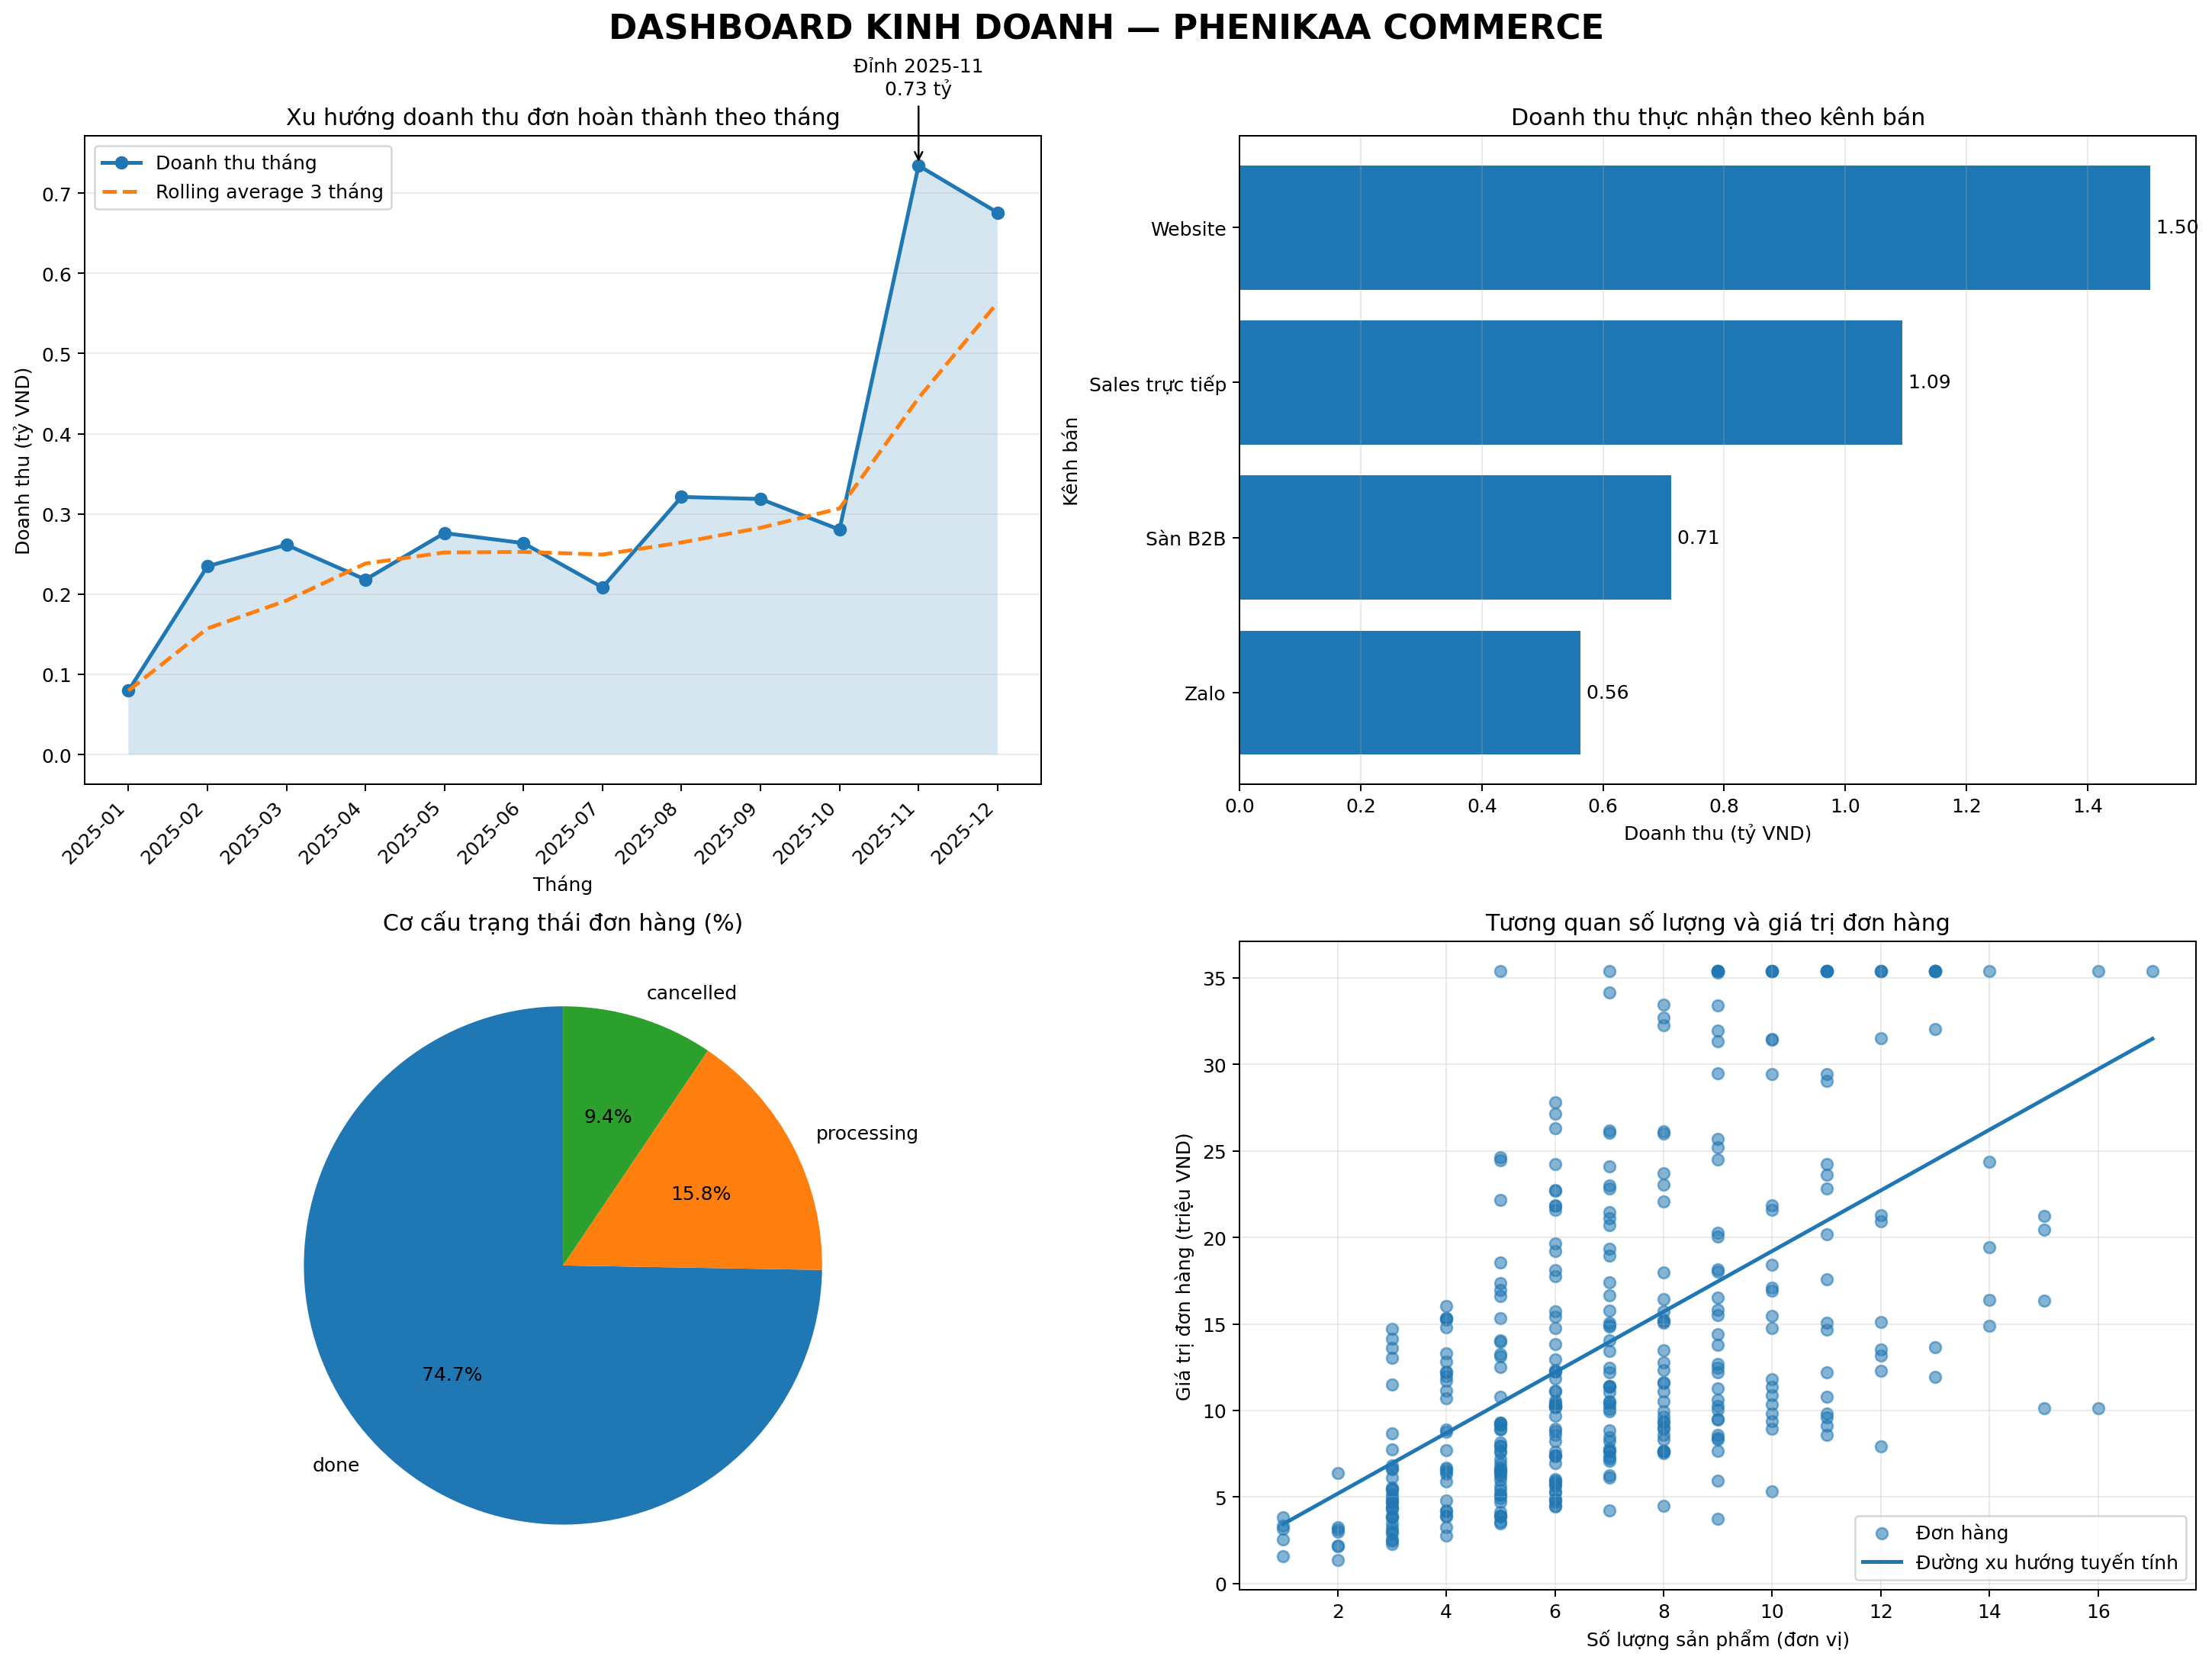

In [11]:
# 4.1. Dashboard Matplotlib với GridSpec và 4 biểu đồ bắt buộc
plt.close("all")
fig = plt.figure(figsize=(16, 12), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

# [1] Line chart + fill_between + rolling average + annotation đỉnh
ax1 = fig.add_subplot(gs[0, 0])
months_plot = doanh_thu_thang.index.to_numpy()
revenue_billion = doanh_thu_thang["doanh_thu"].to_numpy(dtype=float) / 1e9
rolling_billion = doanh_thu_thang["rolling_3_thang"].to_numpy(dtype=float) / 1e9
x_pos = np.arange(len(months_plot))
ax1.plot(x_pos, revenue_billion, marker="o", linewidth=2, label="Doanh thu tháng")
ax1.fill_between(x_pos, revenue_billion, alpha=0.18)
ax1.plot(x_pos, rolling_billion, linestyle="--", linewidth=2, label="Rolling average 3 tháng")
peak_idx = int(np.argmax(revenue_billion))
ax1.annotate(
    f"Đỉnh {months_plot[peak_idx]}\n{revenue_billion[peak_idx]:.2f} tỷ",
    xy=(peak_idx, revenue_billion[peak_idx]),
    xytext=(peak_idx, revenue_billion[peak_idx] * 1.12),
    arrowprops={"arrowstyle": "->"},
    ha="center",
)
ax1.set_title("Xu hướng doanh thu đơn hoàn thành theo tháng")
ax1.set_xlabel("Tháng")
ax1.set_ylabel("Doanh thu (tỷ VND)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(months_plot, rotation=45, ha="right")
ax1.legend()
ax1.grid(axis="y", alpha=0.25)

# [2] Horizontal bar: doanh thu theo kênh
ax2 = fig.add_subplot(gs[0, 1])
channel_plot = phan_tich_kenh.sort_values("tong_doanh_thu", ascending=True)
ax2.barh(channel_plot.index, channel_plot["tong_doanh_thu"] / 1e9)
ax2.set_title("Doanh thu thực nhận theo kênh bán")
ax2.set_xlabel("Doanh thu (tỷ VND)")
ax2.set_ylabel("Kênh bán")
for y, value in enumerate(channel_plot["tong_doanh_thu"] / 1e9):
    ax2.text(value, y, f" {value:.2f}", va="center")
ax2.grid(axis="x", alpha=0.25)

# [3] Pie chart: cơ cấu trạng thái đơn
ax3 = fig.add_subplot(gs[1, 0])
status_counts = df_orders["trang_thai"].value_counts()
ax3.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
ax3.set_title("Cơ cấu trạng thái đơn hàng (%)")

# [4] Scatter + đường xu hướng polyfit
ax4 = fig.add_subplot(gs[1, 1])
x_scatter = df_orders["so_luong"].to_numpy(dtype=float)
y_scatter = df_orders["gia_tri"].to_numpy(dtype=float) / 1e6
ax4.scatter(x_scatter, y_scatter, alpha=0.55, label="Đơn hàng")
coef = np.polyfit(x_scatter, y_scatter, deg=1)
x_line = np.linspace(x_scatter.min(), x_scatter.max(), 100)
y_line = np.polyval(coef, x_line)
ax4.plot(x_line, y_line, linewidth=2, label="Đường xu hướng tuyến tính")
ax4.set_title("Tương quan số lượng và giá trị đơn hàng")
ax4.set_xlabel("Số lượng sản phẩm (đơn vị)")
ax4.set_ylabel("Giá trị đơn hàng (triệu VND)")
ax4.legend()
ax4.grid(alpha=0.25)

fig.suptitle("DASHBOARD KINH DOANH — PHENIKAA COMMERCE", fontsize=18, fontweight="bold")
fig.savefig(MATPLOTLIB_FILE, dpi=180, bbox_inches="tight")
plt.close(fig)
print(f"Đã lưu: {MATPLOTLIB_FILE.resolve()}")
display(Image(filename=str(MATPLOTLIB_FILE)))

Đã lưu: /mnt/data/MSVs_CSE703185/dashboard_seaborn.png


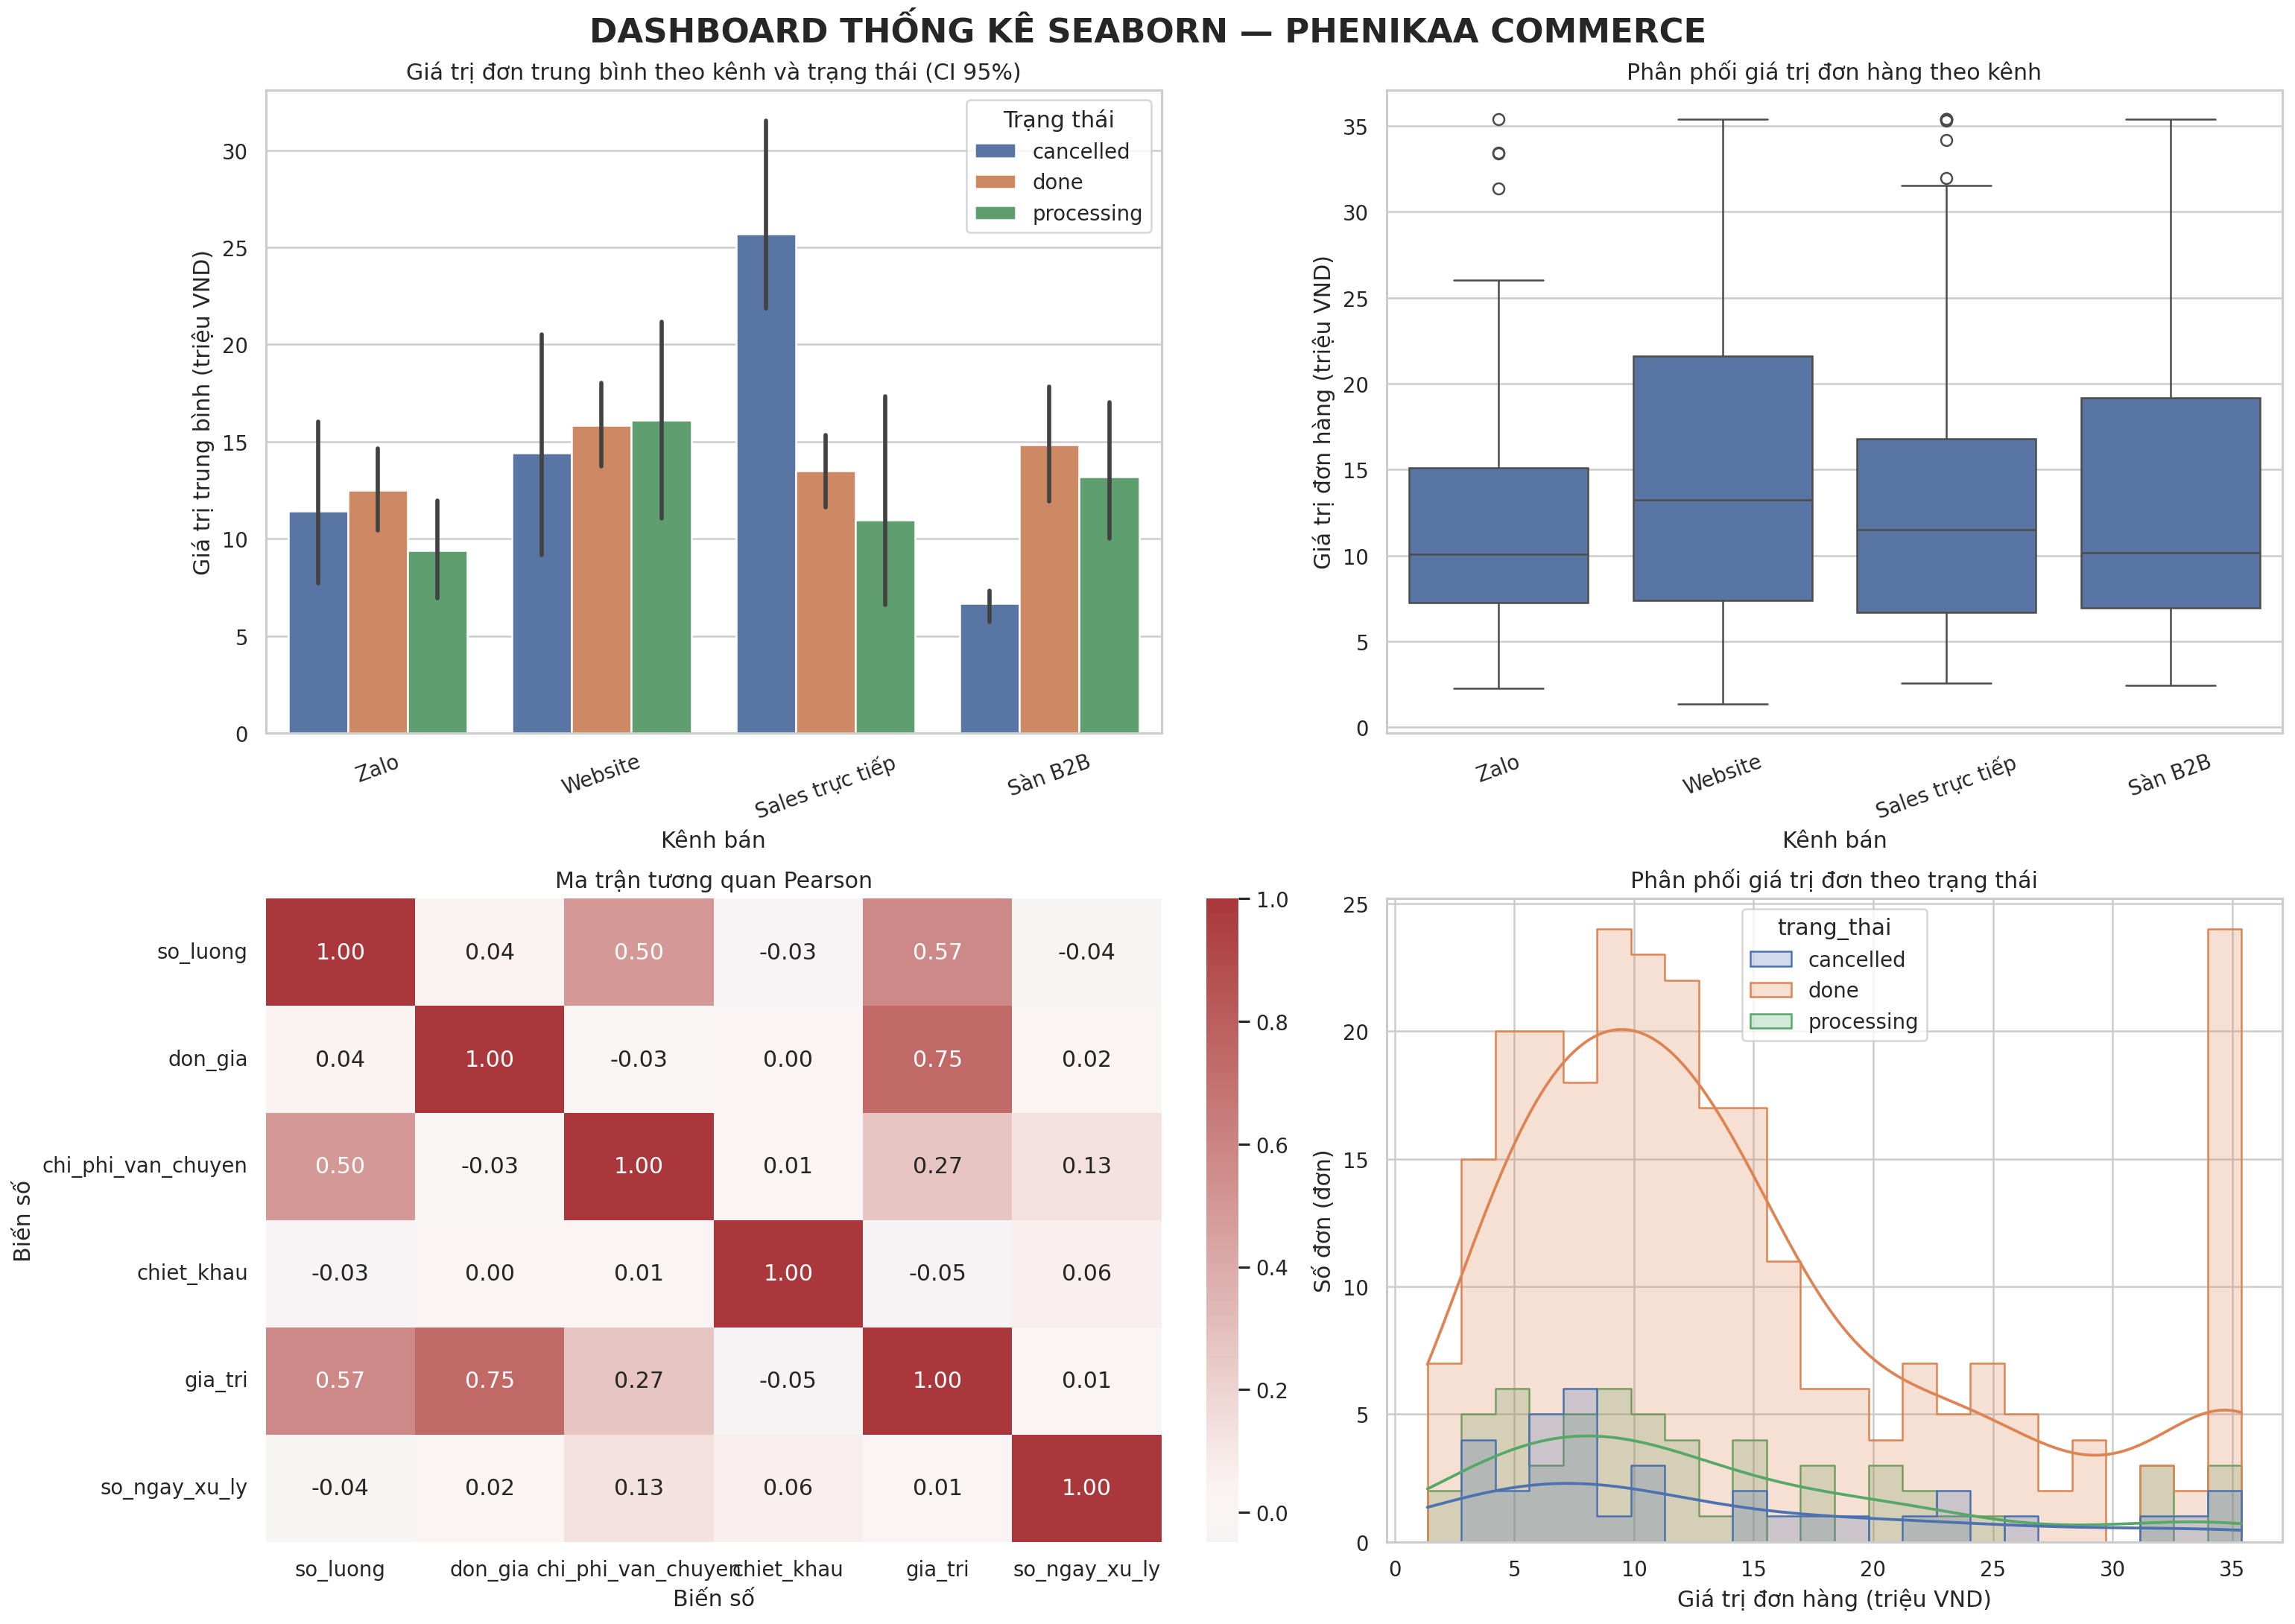

Đã lưu Pairplot thưởng: /mnt/data/MSVs_CSE703185/pairplot_seaborn.png


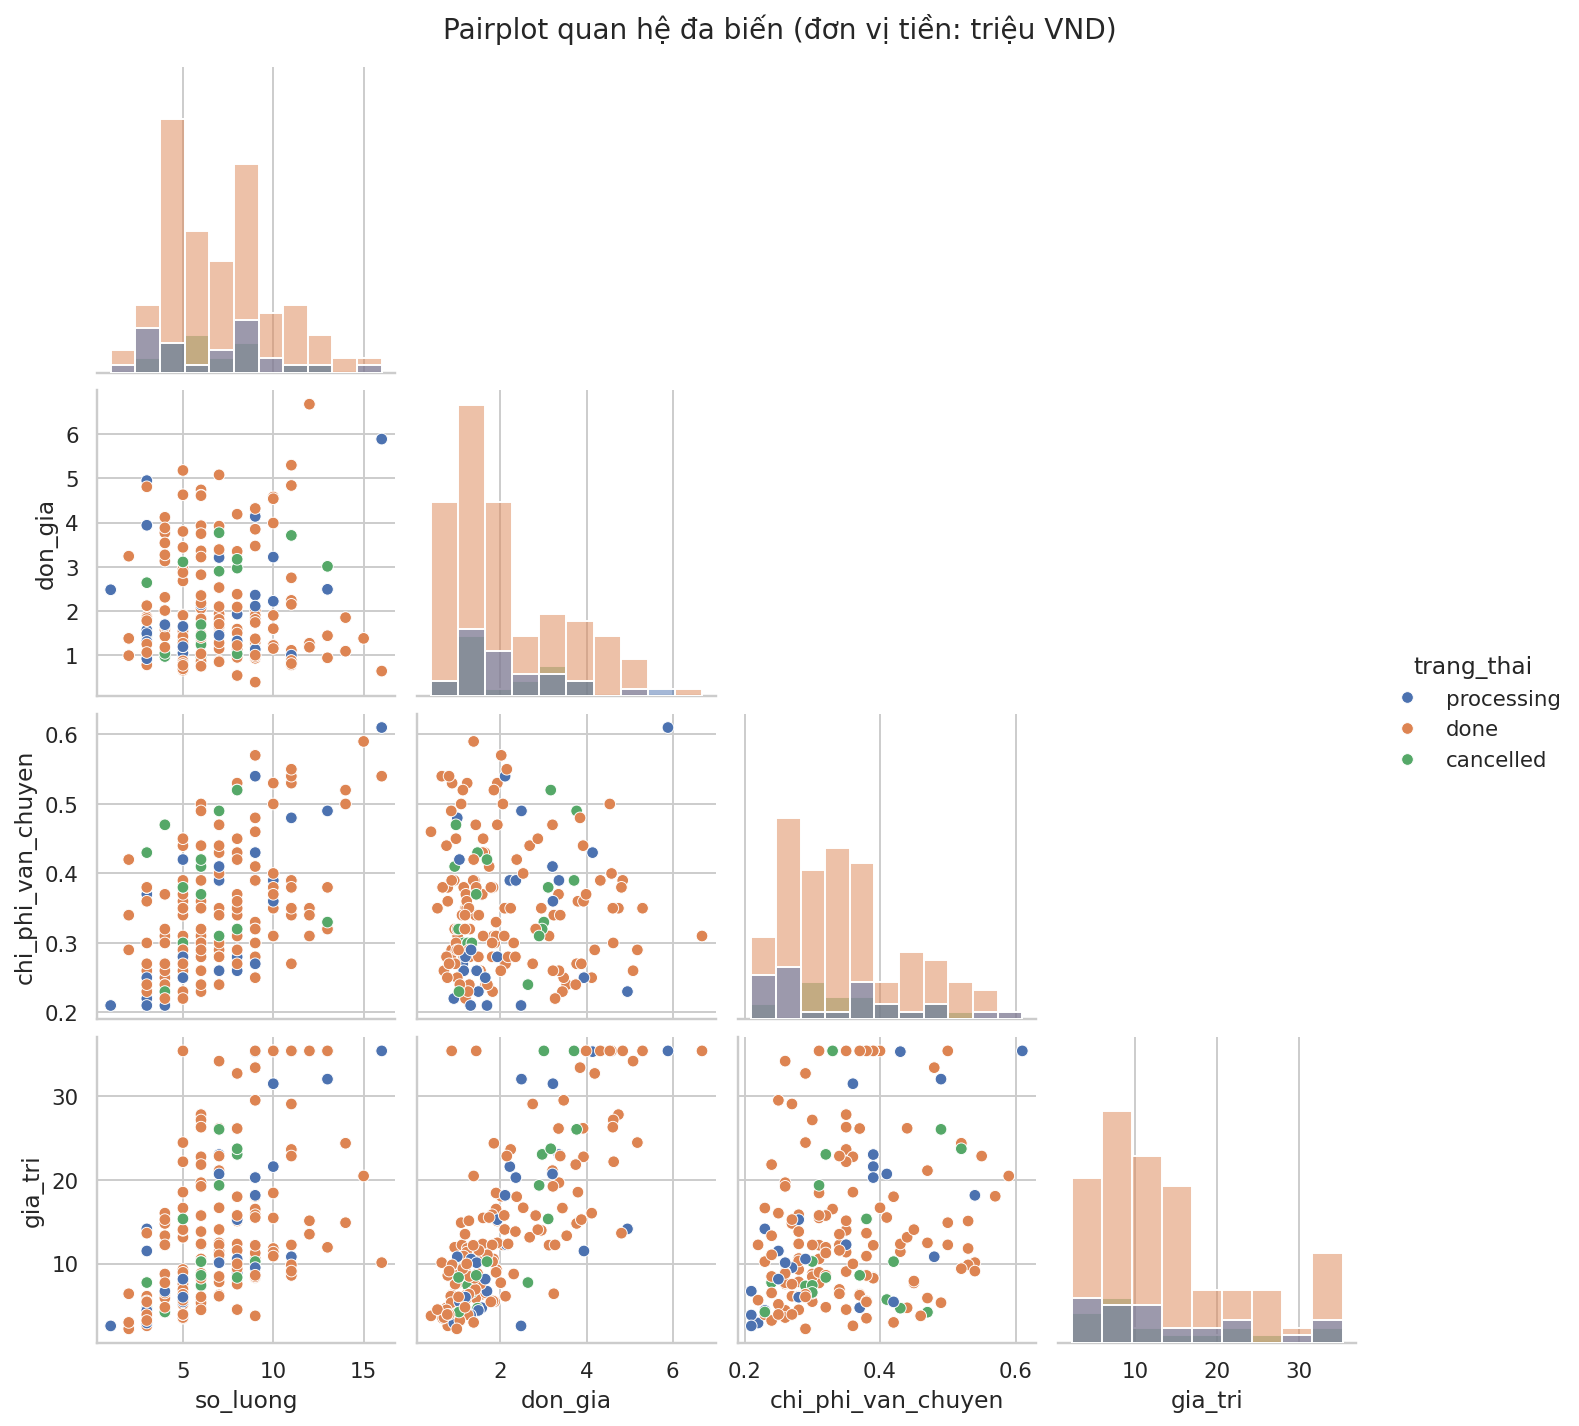

In [12]:
# 4.2. Dashboard Seaborn với 4 loại biểu đồ thống kê
sns.set_theme(style="whitegrid", context="notebook")
plt.close("all")
fig, axes = plt.subplots(2, 2, figsize=(17, 12), constrained_layout=True)

plot_df = df_orders.copy()
plot_df["gia_tri_trieu"] = plot_df["gia_tri"] / 1e6

# [1] Barplot với CI 95%, hue theo trạng thái
sns.barplot(
    data=plot_df,
    x="kenh_ban",
    y="gia_tri_trieu",
    hue="trang_thai",
    estimator=np.mean,
    errorbar=("ci", 95),
    ax=axes[0, 0],
)
axes[0, 0].set_title("Giá trị đơn trung bình theo kênh và trạng thái (CI 95%)")
axes[0, 0].set_xlabel("Kênh bán")
axes[0, 0].set_ylabel("Giá trị trung bình (triệu VND)")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 0].legend(title="Trạng thái")

# [2] Boxplot: phân phối giá trị đơn giữa các kênh
sns.boxplot(data=plot_df, x="kenh_ban", y="gia_tri_trieu", ax=axes[0, 1])
axes[0, 1].set_title("Phân phối giá trị đơn hàng theo kênh")
axes[0, 1].set_xlabel("Kênh bán")
axes[0, 1].set_ylabel("Giá trị đơn hàng (triệu VND)")
axes[0, 1].tick_params(axis="x", rotation=20)

# [3] Heatmap tương quan
sns.heatmap(ma_tran_tuong_quan, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1, 0])
axes[1, 0].set_title("Ma trận tương quan Pearson")
axes[1, 0].set_xlabel("Biến số")
axes[1, 0].set_ylabel("Biến số")

# [4] Histplot phân phối giá trị đơn, có hue
sns.histplot(
    data=plot_df,
    x="gia_tri_trieu",
    hue="trang_thai",
    bins=24,
    kde=True,
    element="step",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Phân phối giá trị đơn theo trạng thái")
axes[1, 1].set_xlabel("Giá trị đơn hàng (triệu VND)")
axes[1, 1].set_ylabel("Số đơn (đơn)")

fig.suptitle("DASHBOARD THỐNG KÊ SEABORN — PHENIKAA COMMERCE", fontsize=18, fontweight="bold")
fig.savefig(SEABORN_FILE, dpi=180, bbox_inches="tight")
plt.close(fig)
print(f"Đã lưu: {SEABORN_FILE.resolve()}")
display(Image(filename=str(SEABORN_FILE)))

# Điểm thưởng: Pairplot có hue, lấy mẫu để file gọn và dễ quan sát.
pairplot_df = plot_df[["so_luong", "don_gia", "chi_phi_van_chuyen", "gia_tri", "trang_thai"]].sample(
    n=min(180, len(plot_df)), random_state=RANDOM_SEED
).copy()
pairplot_df["don_gia"] = pairplot_df["don_gia"] / 1e6
pairplot_df["chi_phi_van_chuyen"] = pairplot_df["chi_phi_van_chuyen"] / 1e6
pairplot_df["gia_tri"] = pairplot_df["gia_tri"] / 1e6

g = sns.pairplot(pairplot_df, hue="trang_thai", corner=True, diag_kind="hist")
g.fig.suptitle("Pairplot quan hệ đa biến (đơn vị tiền: triệu VND)", y=1.02)
g.fig.savefig(PAIRPLOT_FILE, dpi=140, bbox_inches="tight")
plt.close(g.fig)
print(f"Đã lưu Pairplot thưởng: {PAIRPLOT_FILE.resolve()}")
display(Image(filename=str(PAIRPLOT_FILE), width=900))

# PHẦN 5 — BÁO CÁO TỔNG KẾT VÀ ĐỀ XUẤT

Các nhận xét bên dưới được tính trực tiếp từ `df_orders` sau làm sạch, do đó luôn khớp với bảng và biểu đồ trong notebook.

In [13]:
# 5.1. Tóm tắt dự án và 5.2. Đề xuất cải tiến gắn với số liệu

tong_doanh_thu = df_orders["doanh_thu_thuc"].sum()
so_don_hoan_thanh = int(df_orders["hoan_thanh"].sum())
aov = df_orders.loc[df_orders["hoan_thanh"], "gia_tri"].mean()
ty_le_huy = df_orders["trang_thai"].eq("cancelled").mean() * 100

channel_rank = phan_tich_kenh.sort_values("tong_doanh_thu", ascending=False)
region_rank = doanh_thu_khu_vuc.sort_values("doanh_thu", ascending=False)

print("=" * 72)
print("EXECUTIVE SUMMARY — PHENIKAA COMMERCE")
print("=" * 72)
print(f"Tổng doanh thu đơn hoàn thành: {tong_doanh_thu:,.0f} VND")
print(f"Số đơn hoàn thành: {so_don_hoan_thanh}/{len(df_orders)} đơn")
print(f"AOV đơn hoàn thành: {aov:,.0f} VND/đơn")
print(f"Tỷ lệ hủy đơn: {ty_le_huy:.2f}%")
print(f"Tháng bứt phá nhất: {thang_cao_nhat} ({doanh_thu_thang.loc[thang_cao_nhat, 'doanh_thu']:,.0f} VND)")

print("\nTop kênh theo doanh thu:")
for name, row in channel_rank.head(3).iterrows():
    print(f"- {name}: {row['tong_doanh_thu']:,.0f} VND; hoàn thành {row['ty_le_hoan_thanh']:.1f}%")
print("Kênh kém nhất:")
for name, row in channel_rank.tail(1).iterrows():
    print(f"- {name}: {row['tong_doanh_thu']:,.0f} VND; hoàn thành {row['ty_le_hoan_thanh']:.1f}%")

print("\nTop khu vực theo doanh thu:")
for name, row in region_rank.head(3).iterrows():
    print(f"- {name}: {row['doanh_thu']:,.0f} VND; đóng góp {row['ty_trong_%']:.1f}%")
print("Khu vực kém nhất:")
for name, row in region_rank.tail(1).iterrows():
    print(f"- {name}: {row['doanh_thu']:,.0f} VND; đóng góp {row['ty_trong_%']:.1f}%")

# Các vấn đề phát hiện
cancel_by_channel = df_orders.groupby("kenh_ban")["trang_thai"].apply(lambda s: s.eq("cancelled").mean() * 100).sort_values(ascending=False)
worst_cancel_channel = cancel_by_channel.index[0]
worst_cancel_rate = cancel_by_channel.iloc[0]
overall_cancel_rate = ty_le_huy

monthly_growth = doanh_thu_thang["doanh_thu"].pct_change() * 100
worst_growth_month = monthly_growth.idxmin()
worst_growth_value = monthly_growth.min()

print("\nVẤN ĐỀ PHÁT HIỆN")
print(
    f"1) Kênh {worst_cancel_channel} có tỷ lệ hủy {worst_cancel_rate:.1f}%, "
    f"cao hơn mức toàn hệ thống {overall_cancel_rate:.1f}% {worst_cancel_rate / overall_cancel_rate:.2f} lần."
)
print(
    f"2) Doanh thu tháng {worst_growth_month} giảm {abs(worst_growth_value):.1f}% so với tháng trước, "
    "cho thấy rủi ro biến động theo mùa/tháng."
)
print(
    f"3) Trước làm sạch phát hiện {outlier_before} ngoại lệ giá trị và {duplicate_before} dòng trùng; "
    "nếu không xử lý sẽ làm sai lệch KPI doanh thu."
)

# Đề xuất 1: kênh có tỷ lệ hủy cao nhất
worst_channel_orders = int((df_orders["kenh_ban"] == worst_cancel_channel).sum())
target_cancel = max(10.0, overall_cancel_rate)

# Đề xuất 2: khu vực đóng góp thấp nhất
weak_region = region_rank.index[-1]
weak_region_share = region_rank.iloc[-1]["ty_trong_%"]
weak_region_revenue = region_rank.iloc[-1]["doanh_thu"]

# Đề xuất 3: tận dụng mùa cao điểm
peak_revenue = doanh_thu_thang.loc[thang_cao_nhat, "doanh_thu"]
avg_monthly_revenue = doanh_thu_thang["doanh_thu"].mean()
peak_uplift = (peak_revenue / avg_monthly_revenue - 1) * 100

print("\nĐỀ XUẤT CẢI TIẾN — XẾP THEO ƯU TIÊN")
print(
    f"Ưu tiên 1 — Giảm hủy ở kênh {worst_cancel_channel}: kênh này có {worst_channel_orders} đơn "
    f"và tỷ lệ hủy {worst_cancel_rate:.1f}%. Áp dụng xác nhận hai bước trong 30 phút, nhắc lại tự động "
    f"và chuẩn hóa tư vấn trước khi chốt; mục tiêu đưa tỷ lệ hủy xuống dưới {target_cancel:.1f}% trong quý tới."
)
print(
    f"Ưu tiên 2 — Mở rộng khu vực {weak_region}: doanh thu hiện đạt {weak_region_revenue:,.0f} VND, "
    f"chỉ chiếm {weak_region_share:.1f}% toàn hệ thống. Thử nghiệm gói vận chuyển theo ngưỡng đơn và chiến dịch "
    f"B2B địa phương; mục tiêu tăng tỷ trọng thêm ít nhất 2 điểm % trong 6 tháng."
)
print(
    f"Ưu tiên 3 — Nhân rộng công thức tháng {thang_cao_nhat}: doanh thu {peak_revenue:,.0f} VND, "
    f"cao hơn trung bình tháng {peak_uplift:.1f}%. Chuẩn bị tồn kho và ngân sách marketing trước cao điểm 4–6 tuần; "
    "mục tiêu duy trì doanh thu hai tháng cao điểm ở mức tối thiểu 90% tháng đỉnh."
)

print("\nPHÂN CÔNG NHIỆM VỤ")
print("- Bài làm cá nhân: sinh viên thực hiện tạo dữ liệu, lập trình, phân tích, trực quan hóa và viết báo cáo.")

EXECUTIVE SUMMARY — PHENIKAA COMMERCE
Tổng doanh thu đơn hoàn thành: 3,872,520,000 VND
Số đơn hoàn thành: 269/360 đơn
AOV đơn hoàn thành: 14,395,985 VND/đơn
Tỷ lệ hủy đơn: 9.44%
Tháng bứt phá nhất: 2025-11 (734,370,000 VND)

Top kênh theo doanh thu:
- Website: 1,503,930,000 VND; hoàn thành 76.0%
- Sales trực tiếp: 1,093,830,000 VND; hoàn thành 85.3%
- Sàn B2B: 712,110,000 VND; hoàn thành 67.6%
Kênh kém nhất:
- Zalo: 562,650,000 VND; hoàn thành 65.2%

Top khu vực theo doanh thu:
- HCM: 1,153,480,000 VND; đóng góp 29.8%
- HN: 1,073,160,000 VND; đóng góp 27.7%
- Đà Nẵng: 641,600,000 VND; đóng góp 16.6%
Khu vực kém nhất:
- Hải Phòng: 469,120,000 VND; đóng góp 12.1%

VẤN ĐỀ PHÁT HIỆN
1) Kênh Zalo có tỷ lệ hủy 21.7%, cao hơn mức toàn hệ thống 9.4% 2.30 lần.
2) Doanh thu tháng 2025-07 giảm 21.0% so với tháng trước, cho thấy rủi ro biến động theo mùa/tháng.
3) Trước làm sạch phát hiện 26 ngoại lệ giá trị và 3 dòng trùng; nếu không xử lý sẽ làm sai lệch KPI doanh thu.

ĐỀ XUẤT CẢI TIẾN — XẾP TH

In [14]:
# Kiểm tra cuối cùng trước khi nộp
required_files = [MATPLOTLIB_FILE, SEABORN_FILE, PAIRPLOT_FILE]
for file_path in required_files:
    assert file_path.exists() and file_path.stat().st_size > 0, f"Thiếu file: {file_path}"

print("KIỂM TRA HOÀN TẤT")
print(f"- DataFrame sau làm sạch: {df_orders.shape[0]} dòng × {df_orders.shape[1]} cột")
print(f"- NaN còn lại: {int(df_orders.isna().sum().sum())}")
print(f"- Dòng trùng còn lại: {int(df_orders.duplicated().sum())}")
for file_path in required_files:
    print(f"- {file_path.name}: {file_path.stat().st_size / 1024:.1f} KB")
print("Notebook đã đáp ứng các hạng mục chính của đề.")

KIỂM TRA HOÀN TẤT
- DataFrame sau làm sạch: 360 dòng × 16 cột
- NaN còn lại: 0
- Dòng trùng còn lại: 0
- dashboard_matplotlib.png: 406.2 KB
- dashboard_seaborn.png: 365.7 KB
- pairplot_seaborn.png: 274.5 KB
Notebook đã đáp ứng các hạng mục chính của đề.
